In [2]:
!pip install gensim

In [3]:
!pip install pyLDAvis

In [4]:
import pandas as pd

import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

import spacy
import string
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
import matplotlib.pyplot as plt

import pyLDAvis
import pyLDAvis.gensim

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [5]:
# remove stopwords, punctuation, and normalize the corpus
stop = set(stopwords.words('english'))

In [6]:
df = pd.read_csv('./gigs_cleaned.csv')
print(f'Dataset Size: {str(len(df))}')
df.head()

Dataset Size: 5827


,Unnamed: 0,URL_ID,GIG_LINK,SCRAPED,QUALITY,VALUE_OF_DELIVERY,REVIEWS,RATING,NUMBER_OF_WORDS,REPEATING_CUSTOMERS,...,GIG_DESCRIPTION,REPEATING_CUSTOMERS_STANDARDIZED,COMMUNICATION_STANDARDIZED,QUALITY_STANDARDIZED,VALUE_OF_DELIVERY_STANDARDIZED,REVIEWS_STANDARDIZED,RATING_STANDARDIZED,NUMBER_OF_WORDS_STANDARDIZED,RATING_BINNED,NUMBER_OF_WORDS_BINNED
0,0,33352,/msfedawy/build-your-3d-models-and-make-a-real...,1,4.9,4.8,5.0,4.9,992.0,0.0,...,Hello Fiverr\n>>Dont place an order without ta...,-1.204815,0.261906,0.168472,0.080784,0.716825,0.161861,1.736676,Best,Long
1,1,33363,/gputra/create-surreal-psychedelic-and-trippy-...,1,4.9,4.9,3.0,5.0,728.0,1.0,...,Welcome\nMy name is Galih Putra. As a professi...,-0.628707,0.261906,0.168472,0.198056,-1.100026,0.279010,0.807830,Best,Long
2,2,33369,/eminentsage/make-2d-3d-character-animation-fo...,1,5.0,5.0,5.0,5.0,947.0,4.0,...,Hello there!\nAre you looking for captivating ...,1.099619,0.261906,0.285382,0.315328,0.716825,0.279010,1.578350,Best,Long
3,3,33357,/cassmerry/produce-a-fast-and-professional-voi...,1,5.0,4.9,5.0,5.0,491.0,5.0,...,Send me a message for more info on samples and...,1.675727,0.261906,0.285382,0.198056,0.716825,0.279010,-0.026021,Best,Medium
4,4,29859,/wix_buddy/design-or-redesign-squarespace-webs...,1,4.9,4.9,2.0,4.9,588.0,2.0,...,Hi Fiverr Community\nIf you are looking for a ...,-0.052598,0.145069,0.168472,0.198056,-2.008452,0.161861,0.315260,Best,Long


In [7]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
def lemmatization(text, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
  doc = nlp(text)
  new_text = []
  for token in doc:
    if token.pos_ in allowed_postags:
      new_text.append(token.lemma_)
  final = " ".join(new_text)
  return final

In [8]:
df['LEMMATIZED_DESCRIPTION'] = df['GIG_DESCRIPTION'].apply(lemmatization)

In [9]:
df['LEMMATIZED_DESCRIPTION'].head()

,LEMMATIZED_DESCRIPTION
0,place order talk first note gig product only m...
1,welcome name professional illustrator experien...
2,there look captivate 3d character animation me...
3,send message more info sample startup bulk pro...
4,look brand new website design need make change...


In [10]:
def remove_stopwords(text):
  result = []
  for token in simple_preprocess(text, deacc=True):
    if token not in stop:
      result.append(token)
  return result

In [11]:
df['LEMMATIZED_DESCRIPTION'] = df['LEMMATIZED_DESCRIPTION'].apply(remove_stopwords)

In [12]:
#Bigrams and Trigrams
bigrams_phrases = gensim.models.Phrases(df['LEMMATIZED_DESCRIPTION'].to_list(), min_count=5, threshold=100)
trigrams_phrases = gensim.models.Phrases(bigrams_phrases[df['LEMMATIZED_DESCRIPTION'].to_list()], threshold=100)

bigram = gensim.models.phrases.Phraser(bigrams_phrases)
trigram = gensim.models.phrases.Phraser(trigrams_phrases)

def make_bigrams(texts):
  return [bigram[doc] for doc in texts]

def make_trigrams(texts):
  return [trigram[bigram[doc]] for doc in texts]

data_bigrams = make_bigrams(df['LEMMATIZED_DESCRIPTION'].to_list())
data_bigrams_trigrams = make_trigrams(data_bigrams)

print(data_bigrams_trigrams)

[['place', 'order', 'talk', 'first', 'note', 'gig', 'product', 'model', 'character', 'note', 'cost', 'depend_complexity', 'job', 'cost', 'less', 'read', 'designer', 'modeling', 'realistic', 'rending', 'well', 'design', 'kind', 'part', 'product', 'assembly', 'fixture', 'enclosure', 'bottle', 'instrument', 'case', 'prototype', 'technical_drawing', 'many', 'provide', 'high', 'quality', 'maintain', 'excellence', 'level', 'good', 'follow', 'service', 'provide', 'model', 'use', 'work', 'realistic', 'rendering', 'keyshot', 'use', 'organic', 'modeling', 'short', 'complete', 'package', 'work', 'hesitate', 'contact', 'question', 'available', 'good'], ['welcome', 'name', 'professional', 'illustrator', 'experience', 'make', 'illustration', 'character', 'design', 'shirt', 'design', 'merchandise', 'album', 'cover', 'poster', 'packaging', 'design', 'style', 'artwork', 'psychedelic', 'colorful', 'surreal', 'trippy', 'work', 'professional', 'high', 'detail', 'quality', 'illustration', 'responsive', 'de

In [13]:
#TF-IDF Removal
from gensim.models import TfidfModel

id2word = corpora.Dictionary(data_bigrams_trigrams)

texts = data_bigrams_trigrams

corpus = [id2word.doc2bow(text) for text in texts]

tfidf = TfidfModel(corpus, id2word=id2word)

low_value = 0.10
words = []
words_missing_in_tfidf = []
for i in range(0, len(corpus)):
  bow = corpus[i]
  low_value_words = []
  tfidf_ids = [id for id, value in tfidf[bow]]
  bow_ids = [id for id, value in bow]
  low_value_words = [id for id, value in tfidf[bow] if value < low_value]
  drops = low_value_words + words_missing_in_tfidf
  for item in drops:
    words.append(id2word[item])
  words_missing_in_tfidf = [id for id in bow_ids if id not in tfidf_ids]
  new_bow = [b for b in bow if b[0] not in low_value_words and b[0] not in words_missing_in_tfidf]
  corpus[i] = new_bow


Number of Topics: 4
Number of Topics: 5
Number of Topics: 6
Number of Topics: 7
Number of Topics: 8
Number of Topics: 9
Number of Topics: 10
Number of Topics: 11
Number of Topics: 12
Number of Topics: 13
Number of Topics: 14
Number of Topics: 15
Number of Topics: 16
Number of Topics: 17
Number of Topics: 18
Number of Topics: 19
Number of Topics: 20
Number of Topics: 21
Number of Topics: 22
Number of Topics: 23
Number of Topics: 24


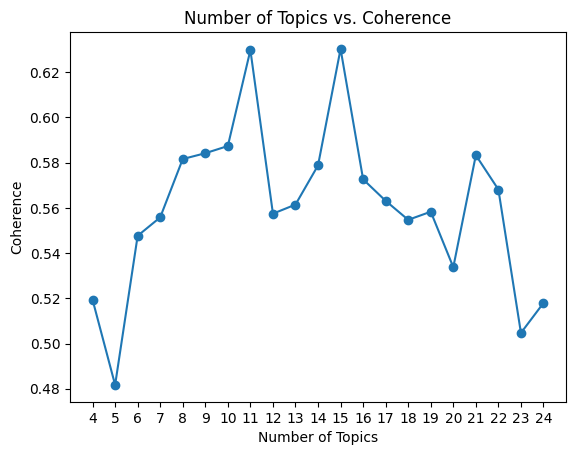

In [19]:
coherence = []
for k in range(4, 25):
  print(f'Number of Topics: {str(k)}')
  lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, num_topics=k, iterations=200, update_every=1, chunksize=1000, passes=20, alpha='auto')
  cm = gensim.models.coherencemodel.CoherenceModel(model=lda_model, texts=data_bigrams_trigrams, dictionary=id2word, coherence='c_v')
  coherence.append((k, cm.get_coherence()))
x_val = [x[0] for x in coherence]
y_val = [x[1] for x in coherence]
plt.plot(x_val,y_val)
plt.scatter(x_val,y_val)
plt.title('Number of Topics vs. Coherence')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence')
plt.xticks(x_val)
plt.show()

In [20]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, num_topics=15, iterations=200, update_every=1, chunksize=1000, passes=20, alpha='auto')

In [21]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds='mmds', R=20)
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
13    -0.437706 -0.086345       1        1  19.119834
3      0.076673 -0.127951       2        1  10.329296
4     -0.348065  0.082673       3        1   8.036961
6      0.308143 -0.036870       4        1   6.801961
5      0.367772 -0.207894       5        1   6.735171
10     0.417350  0.157195       6        1   6.263583
2      0.244467  0.329824       7        1   5.901426
0      0.187560 -0.394691       8        1   5.826205
12    -0.302403 -0.283027       9        1   5.641620
7     -0.144483 -0.209021      10        1   4.976952
1     -0.119652  0.301706      11        1   4.939202
14    -0.312279  0.314951      12        1   4.570179
8      0.065908  0.149143      13        1   3.845902
9     -0.041998 -0.420442      14        1   3.789452
11     0.038713  0.430749      15        1   3.222255, topic_info=           Term         Freq        Total Category  logprob  loglift
9        design  1568.000000  1568.000000  Default  20.0000  20.0000
95    animation  1415.000000  1415.000000  Default  19.0000  19.0000
329       music  1221.000000  1221.000000  Default  18.0000  18.0000
36      product  1121.000000  1121.000000  Default  17.0000  17.0000
267       video  1358.000000  1358.000000  Default  16.0000  16.0000
...         ...          ...          ...      ...      ...      ...
330     musical    58.244363    81.190719  Topic15  -4.3826   3.1029
126       skill    76.012067   154.221781  Topic15  -4.1164   2.7276
902        live    56.049746    95.398819  Topic15  -4.4210   2.9033
733        beat    58.890144   110.822510  Topic15  -4.3716   2.8028
1159    improve    49.667502   100.617651  Topic15  -4.5419   2.7291

[524 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1975     14  0.967557   ability
390      10  0.983786    accent
747       7  0.052610   account
747      11  0.940403   account
819       8  0.990334  accurate
...     ...       ...       ...
507       6  0.674873     write
507      10  0.093334     write
507      12  0.222565     write
354       7  0.992567   youtube
1367      6  0.986732      zoom

[845 rows x 3 columns], R=20, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[14, 4, 5, 7, 6, 11, 3, 1, 13, 8, 2, 15, 9, 10, 12])